In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [131]:
df = pd.read_csv(r'c:\Users\jayax\Downloads\Diwali_Sales_Data.csv')
df.shape

(11251, 15)

In [132]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [134]:
#drop blank columns
df.drop(['Status', 'unnamed1'], axis = 1, inplace = True)

In [135]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [136]:
#drop null values
df.dropna (inplace=True)

In [137]:
#change column type
df['Amount'] = df['Amount'].astype('int')

In [138]:
df["Amount"].dtypes

dtype('int64')

In [139]:
#convert column names to lowercase 
df.columns = df.columns.str.lower()

In [140]:
df.columns

Index(['user_id', 'cust_name', 'product_id', 'gender', 'age group', 'age',
       'marital_status', 'state', 'zone', 'occupation', 'product_category',
       'orders', 'amount'],
      dtype='str')

In [141]:
df.describe()

,user_id,age,marital_status,orders,amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


Exploratory Data Analysis

Gender

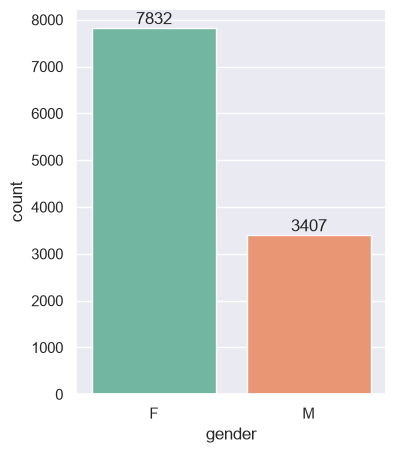

In [158]:
ax = sns.countplot(x = 'gender', data = df , hue = 'gender' , palette='Set2')
sns.set_theme(rc={'figure.figsize':(4,5)})
for bars in ax.containers :
    ax.bar_label(bars)

<Axes: xlabel='gender', ylabel='amount'>

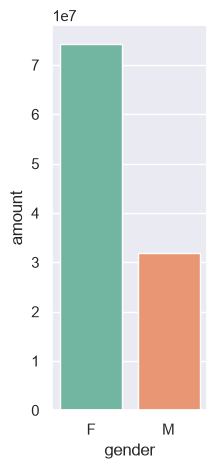

In [144]:
sales_gen = df.groupby(['gender'], as_index = False)['amount'].sum().sort_values(by = 'amount', ascending = False) 
sns.set_theme(rc={'figure.figsize':(2,5)})
sns.barplot (x = 'gender', y = 'amount', data = sales_gen , hue = 'gender', palette='Set2')

*From above graphs we can see that most buyers and purchasing power of females are greater than males*

Age

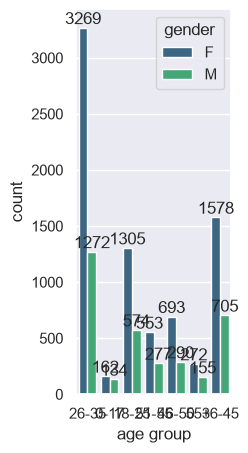

In [145]:
ax = sns.countplot(data = df, x = 'age group', hue = 'gender', palette='viridis')
sns.set_theme(rc={'figure.figsize':(7,5)})


for bars in ax.containers :
    ax.bar_label(bars)

<Axes: xlabel='age group', ylabel='amount'>

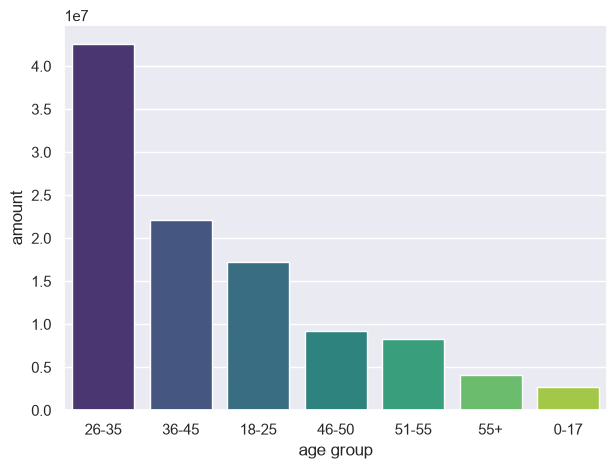

In [146]:
#Total Amount vs Age Group
sales_age = df.groupby(['age group'], as_index = False)['amount'].sum().sort_values(by = 'amount', ascending = False) 
sns.set_theme(rc={'figure.figsize':(7,5)})
sns.barplot(x = 'age group', y= 'amount' ,data = sales_age, hue = 'age group',legend=False, palette='viridis')

*From above graphs we can see that most the the buyers are females from age group 26-35*

States

<Axes: xlabel='state', ylabel='orders'>

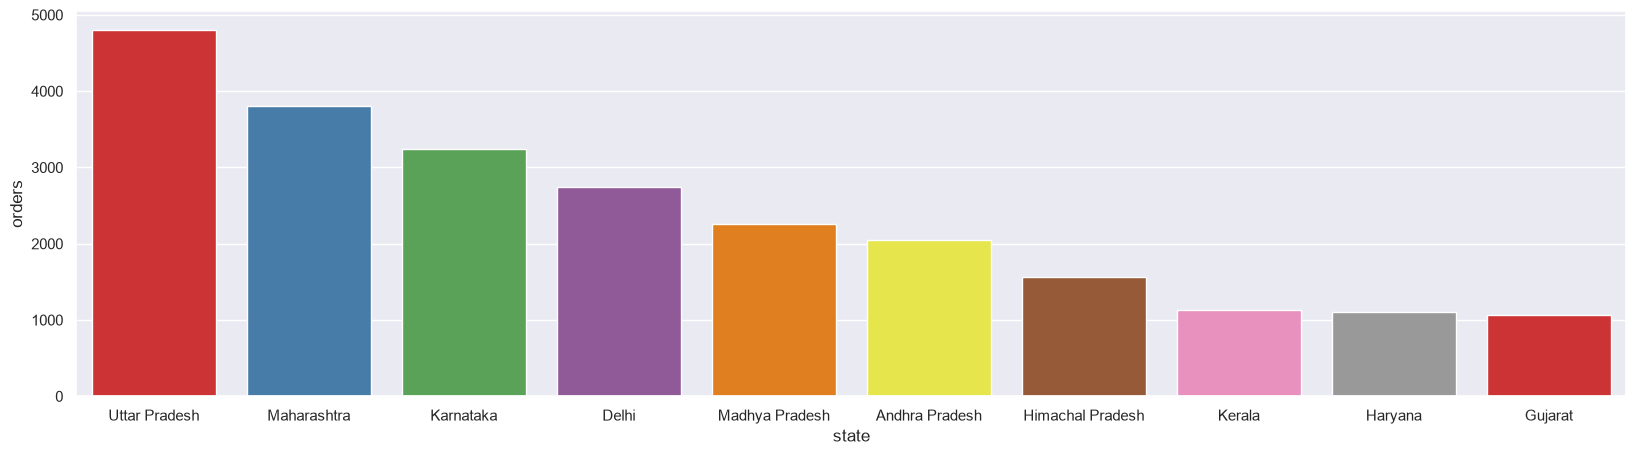

In [147]:
#Total no. of orders from top 10 states
sales_state = df.groupby(['state'], as_index = False)['orders'].sum().sort_values(by = 'orders', ascending = False).head(10) 
sns.set_theme(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'state', y = 'orders', hue = 'state' , legend=False, palette='Set1')

<Axes: xlabel='state', ylabel='amount'>

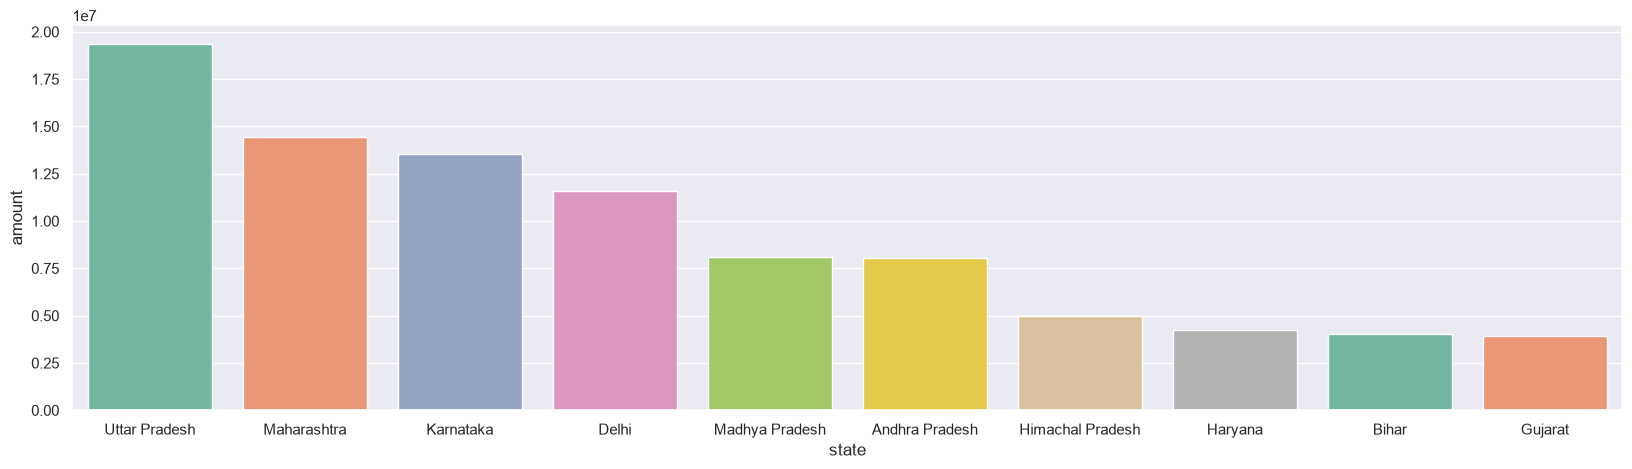

In [148]:
#Total Sales from Top 10 states
sales_state = df.groupby(['state'], as_index = False)['amount'].sum().sort_values(by = 'amount', ascending = False).head(10) 
sns.set_theme(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'state', y = 'amount', hue = 'state', legend = False, palette='Set2')


*From above graphs we can see that most orders and sales are from states Uttar Pradesh, Maharashtra and Karnataka*

Marital Status

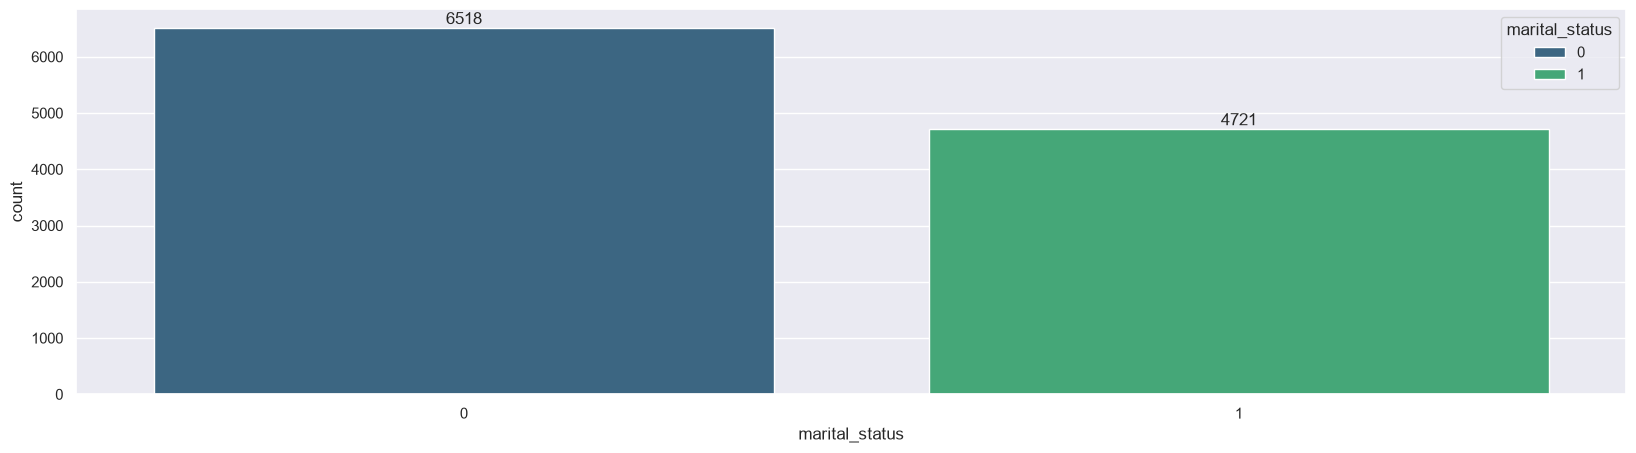

In [149]:
ax = sns.countplot(data = df , x = 'marital_status', hue = 'marital_status', palette='viridis')
sns.set_theme(rc={'figure.figsize':(6,5)})

for bars in ax.containers :
    ax.bar_label(bars)

<Axes: xlabel='marital_status', ylabel='amount'>

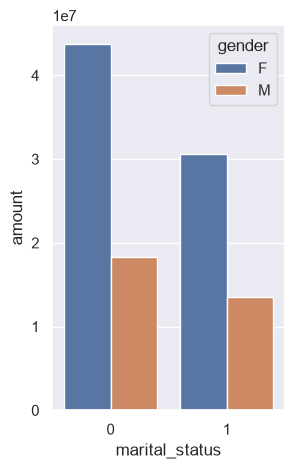

In [150]:
sales_state =  df.groupby(['marital_status', 'gender'], as_index = False)['amount'].sum().sort_values(by = 'amount', ascending = False)
sns.set_theme(rc={'figure.figsize':(3,5)})
sns.barplot(data = sales_state, x = 'marital_status', y = 'amount' , hue = 'gender')

*From above graphs we cans see that most buyers are married woman and they have a higher purchasing power*

Occupation

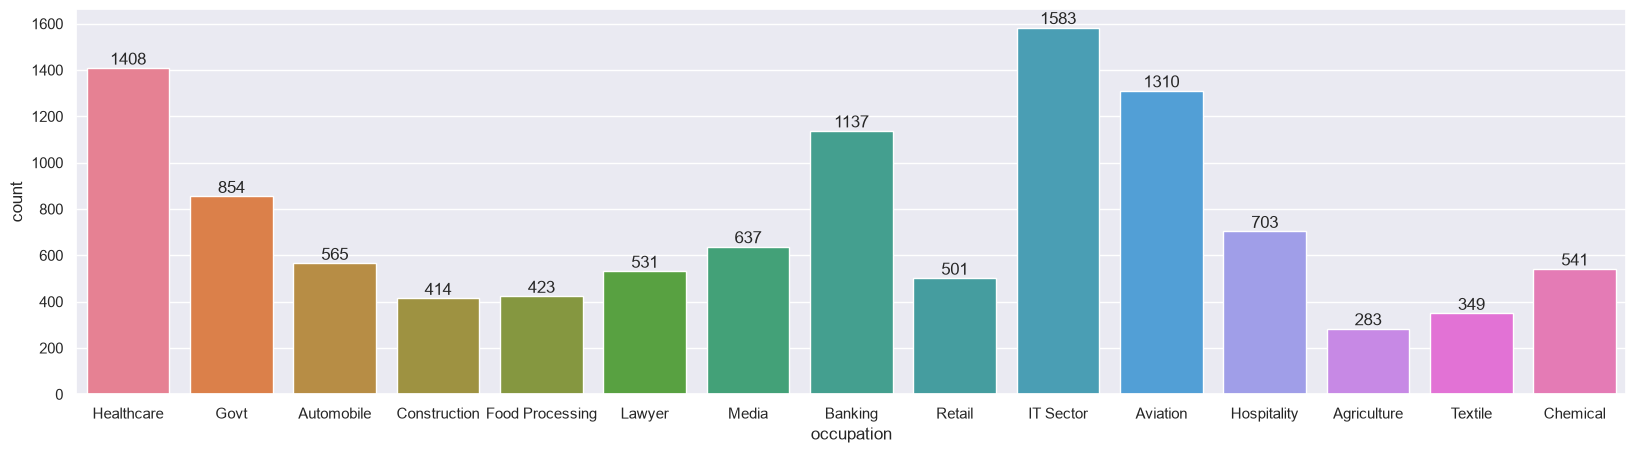

In [151]:
sns.set_theme(rc={'figure.figsize':(20,5)}) 
ax = sns.countplot(data = df , x = 'occupation' , palette='husl', hue = 'occupation')

for bars in ax.containers :
    ax.bar_label(bars)

<Axes: xlabel='occupation', ylabel='amount'>

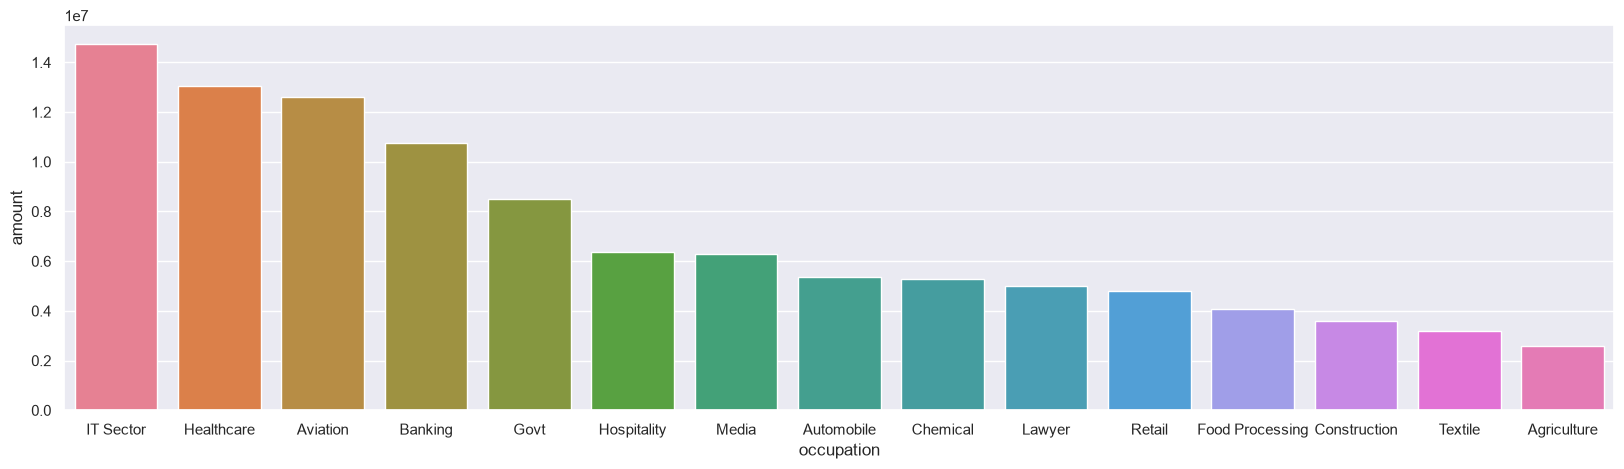

In [152]:
sales_occupation =  df.groupby(['occupation'], as_index = False)['amount'].sum().sort_values(by = 'amount', ascending = False)
sns.set_theme(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_occupation, x = 'occupation', y = 'amount' , hue = 'occupation' , palette = 'husl')

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation*

Product Category

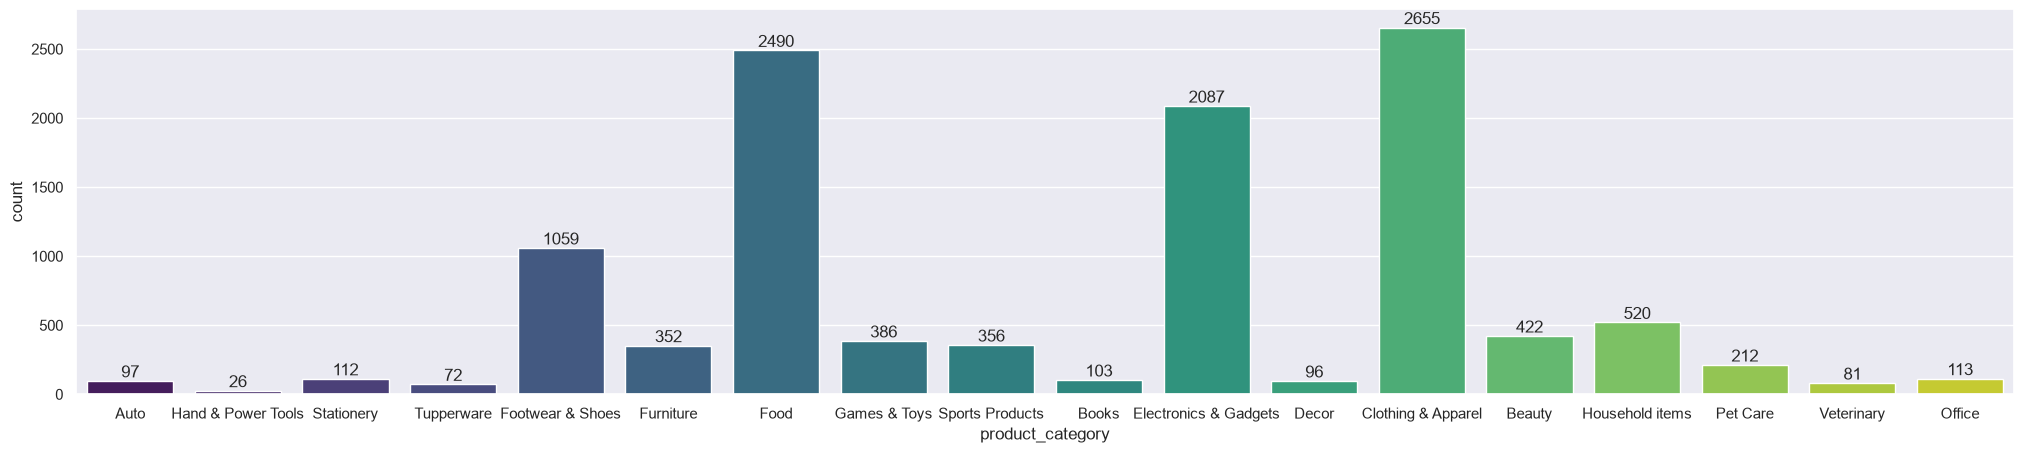

In [153]:
sns.set_theme(rc={'figure.figsize':(25,5)})
ax = sns.countplot(data = df, x = 'product_category', hue = 'product_category' , palette='viridis')

for bars in ax.containers :
    ax.bar_label(bars)

<Axes: xlabel='product_category', ylabel='amount'>

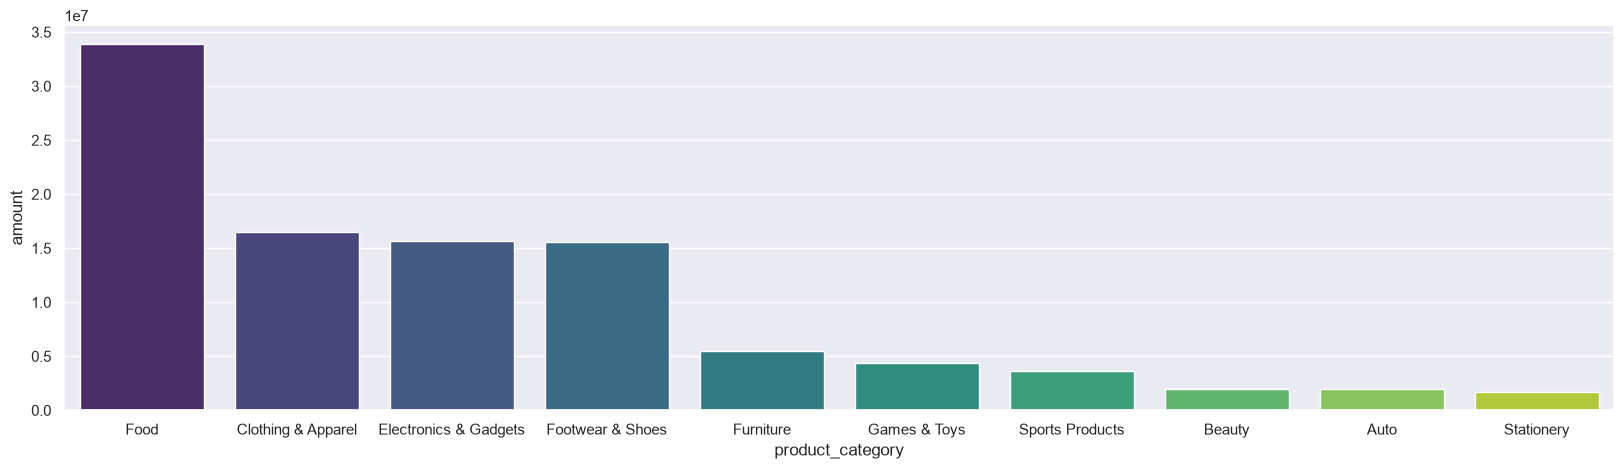

In [154]:
sales_category =  df.groupby(['product_category'], as_index = False)['amount'].sum().sort_values(by = 'amount', ascending = False).head(10)
sns.set_theme(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_category, x = 'product_category', y = 'amount' , hue = 'product_category' , palette = 'viridis')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

<Axes: xlabel='product_id'>

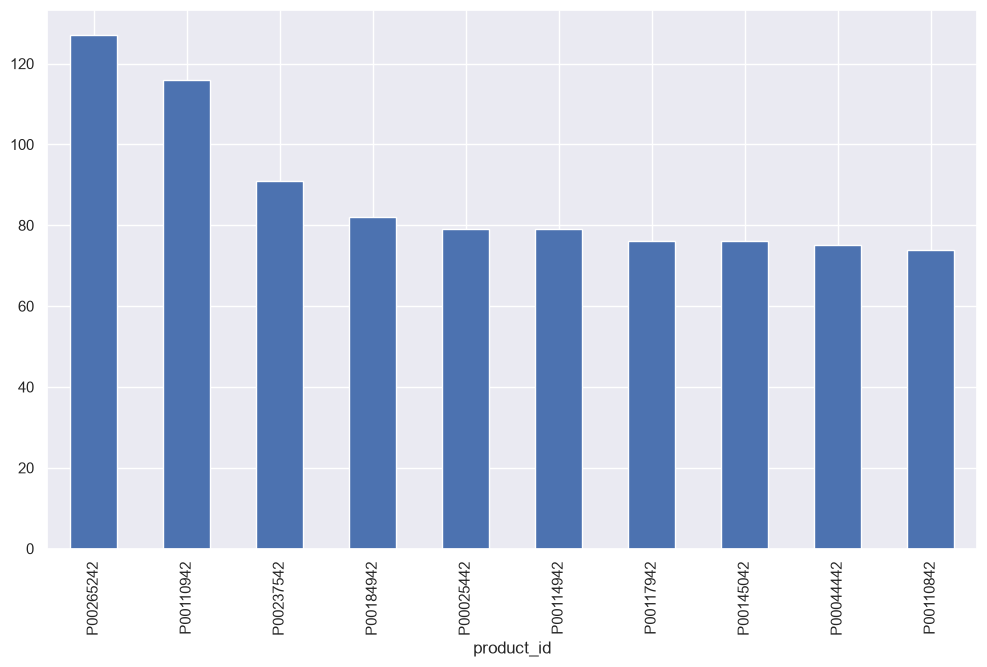

In [155]:
#Top 10 most sold products
fig1, ax1 = plt.subplots(figsize = (12,7))
df.groupby('product_id')['orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

Conclusion:
*Married women age group 26-35 yrs from UP, Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*